In [57]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

from data_load_utils import load_image, load_data, create_data_frame

import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from cnn_model import Model

In [58]:
from torchvision.models import ResNet50_Weights

## Loading Models

### The single_fc layer ontop of ResNet:

model.fc = nn.Linear(model.fc.in_features, 7)

### The Complex Layer ontop of the ResNet output: 

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(  

    nn.Linear(num_ftrs, 1024),  
    nn.ReLU(),  
    nn.Dropout(0.4),    

    nn.Linear(1024, 512),  
    nn.ReLU(),  
    nn.Dropout(0.3),  

    nn.Linear(512, 7)  
    
    ) 


In [59]:
with open ("./models/sgd.pickle", "rb") as f:
    sgd = pickle.load(f)

In [60]:
cnn = torch.load("./models/cnn_full_model.pth", weights_only = False)

In [61]:
resnet_single_fc = torch.load("./models/resnet50_fine_tuned_single_fc.pth", weights_only = False)

In [62]:
resnet_single_fc_wc = torch.load("./models/resnet50_fine_tuned_single_fc_weighed_classes.pth", weights_only=False)

In [63]:
resnet_complex_fc_wc = torch.load(
    "./models/resnet50_fine_tuned_single_fc_weighed_classes.pth",
    weights_only = False
)

In [64]:
resnet_complex_last_layer_wc = torch.load(
    "./models/resnet50_complex_last_layer_weighed_classes.pth",
    weights_only=False
)

In [65]:
resnet_complex_full_wc = torch.load(
    "./models/resnet50_complex_full_weighed_classes.pth",
    weights_only=False
)

In [66]:
resnet_complex_full = torch.load(
    "./models/resnet50_complex_full.pth",
    weights_only = False
)

In [67]:
resnets = [resnet_single_fc, resnet_single_fc_wc, resnet_complex_fc_wc, resnet_complex_last_layer_wc, resnet_complex_full_wc, resnet_complex_full]

In [68]:
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor()
])

## Load Testing Data

In [69]:
testing_dir = "./data/test"

In [70]:
emotions, images = load_data(testing_dir)
le = LabelEncoder()
labels = le.fit_transform(emotions)

In [71]:
sgd_testing_data = create_data_frame(emotions, labels, images)

In [72]:
def flatten_and_scale(img):
        return img.flatten()/255

def prepare_data_sgd(df):
    X = np.stack(df["image"].apply(flatten_and_scale).values)
    y = df["label"].values
    return X,y

In [73]:
X_test_sgd, y_test_sgd = prepare_data_sgd(sgd_testing_data)

In [74]:
def load_cnn_testing_data(df):
    X_test = np.stack(df["image"].values)
    y_test = df["label"].values
    X_test_tensor = torch.tensor(X_test, dtype = torch.float32)/255
    y_test_tensor = torch.tensor(y_test, dtype = torch.long)
    X_test_tensor = X_test_tensor.unsqueeze(1) 
    testing_data_tensor = TensorDataset(X_test_tensor, y_test_tensor)
    testing_loader = DataLoader(testing_data_tensor, 10, shuffle = False)
    return testing_loader

In [75]:
cnn_testing_loader = load_cnn_testing_data(sgd_testing_data)

In [76]:
resnet_transform = ResNet50_Weights.IMAGENET1K_V2.transforms()

In [77]:
resnet_testing_data = ImageFolder(root = testing_dir, transform = resnet_transform)

In [78]:
resnet_testing_loader = DataLoader(resnet_testing_data, batch_size = 10, shuffle = False)

## Evaluation

In [79]:
results={}

In [80]:
def store_results(y_true, y_pred, model_name):
    results[model_name] = {
        "accuracy_score": accuracy_score(y_true, y_pred),
        "recall_score": recall_score(y_true, y_pred, average = "macro"),
        "precision_score": precision_score(y_true, y_pred, average = "macro"),
        "f1_score": f1_score(y_true, y_pred, average = "macro")
    }
    return results[model_name]

#### SGD

In [81]:
sgd_predictions = sgd.predict(X_test_sgd)

In [82]:
store_results(y_test_sgd, sgd_predictions, "SGD")

C:\Users\Mike\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'accuracy_score': 0.3786570075229869,
 'recall_score': 0.29493417182323795,
 'precision_score': 0.2965161401542127,
 'f1_score': 0.27781807555787275}

#### CNN

In [83]:
cnn_preds = []
cnn_labels = []

In [84]:
cnn.eval()
with torch.no_grad():
    for X_test, y_test in cnn_testing_loader:
        y_pred = cnn(X_test)
        predicted = torch.argmax(y_pred, dim=1)
        cnn_preds.extend(predicted.tolist())
        cnn_labels.extend(y_test.tolist())

In [85]:
store_results(cnn_labels, cnn_preds, "CNN")

{'accuracy_score': 0.561994984675397,
 'recall_score': 0.5096636703794336,
 'precision_score': 0.6122226079266712,
 'f1_score': 0.5338841313887324}

#### ResNet50

In [86]:
def eval_resnet(model):
    model.to("cuda")
    model.eval()
    preds = []
    labels = []
    with torch.no_grad():
        for X_test, y_test in resnet_testing_loader:
            X_test = X_test.to("cuda")
            y_test = y_test.to("cuda")
            predictions = model(X_test)
            y_pred = torch.argmax(predictions, dim=1)
            preds.extend(y_pred.cpu().tolist())
            labels.extend(y_test.cpu().tolist())
    return labels, preds

In [87]:
labels, preds = eval_resnet(resnet_single_fc)
store_results(labels, preds,"ResNet50_SingleFC")

{'accuracy_score': 0.4189189189189189,
 'recall_score': 0.3756489089769233,
 'precision_score': 0.4010026099944958,
 'f1_score': 0.3790420973952486}

In [88]:
labels, preds = eval_resnet(resnet_complex_fc_wc)
store_results(labels, preds,"ResNet50_ComplexFC_WC")

{'accuracy_score': 0.39746447478406244,
 'recall_score': 0.31562464413004826,
 'precision_score': 0.5129160067275129,
 'f1_score': 0.31408547338321374}

In [89]:
labels, preds = eval_resnet(resnet_complex_last_layer_wc)
store_results(labels, preds,"ResNet50_ComplexFC_LastLayer_WC")

C:\Users\Mike\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'accuracy_score': 0.3967679019225411,
 'recall_score': 0.29320605800042066,
 'precision_score': 0.3806986997834037,
 'f1_score': 0.28191371397968656}

In [90]:
labels, preds = eval_resnet(resnet_complex_full_wc)
store_results(labels, preds,"ResNet50_ComplexFC_Full_WC")

C:\Users\Mike\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'accuracy_score': 0.4158539983282251,
 'recall_score': 0.32274835664799145,
 'precision_score': 0.36451841703044724,
 'f1_score': 0.3090432844233613}

In [91]:
labels, preds = eval_resnet(resnet_complex_full)
store_results(labels, preds,"ResNet50_ComplexFC_Full")

C:\Users\Mike\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'accuracy_score': 0.42407355809417663,
 'recall_score': 0.3404243641277644,
 'precision_score': 0.3612100721345505,
 'f1_score': 0.33261453849300693}

In [92]:
for entry in results:
    print(f"{entry} - Accuracy Score: {results[entry]["accuracy_score"]}")

SGD - Accuracy Score: 0.3786570075229869
CNN - Accuracy Score: 0.561994984675397
ResNet50_SingleFC - Accuracy Score: 0.4189189189189189
ResNet50_ComplexFC_WC - Accuracy Score: 0.39746447478406244
ResNet50_ComplexFC_LastLayer_WC - Accuracy Score: 0.3967679019225411
ResNet50_ComplexFC_Full_WC - Accuracy Score: 0.4158539983282251
ResNet50_ComplexFC_Full - Accuracy Score: 0.42407355809417663


In [93]:
sorted_results = dict(
    sorted(results.items(), key=lambda item: item[1]["accuracy_score"], reverse=False)
)

In [96]:
for entry in sorted_results:
    print(entry)

SGD
ResNet50_ComplexFC_LastLayer_WC
ResNet50_ComplexFC_WC
ResNet50_ComplexFC_Full_WC
ResNet50_SingleFC
ResNet50_ComplexFC_Full
CNN


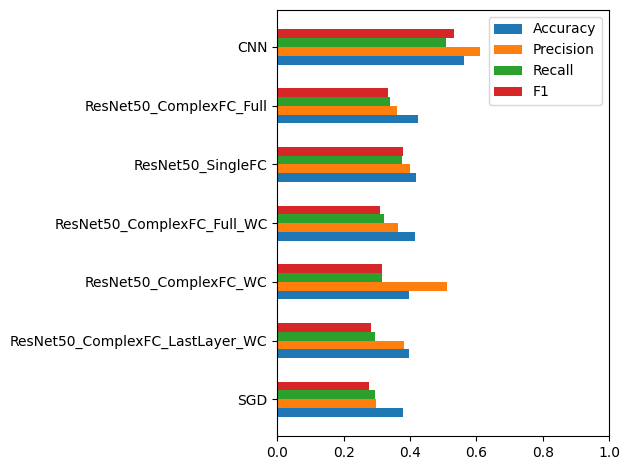

In [97]:
x = np.arange(len(results))
width = 0.15

accuracies = [results[entry]["accuracy_score"]for entry in sorted_results]
precisions = [results[entry]["precision_score"]for entry in sorted_results]
recalls = [results[entry]["recall_score"]for entry in sorted_results]
f1s = [results[entry]["f1_score"]for entry in sorted_results]

plt.barh(x-1.5*width, accuracies , width, label = "Accuracy")
plt.barh(x-0.5*width, precisions, width, label = "Precision")
plt.barh(x+0.5*width, recalls, width, label = "Recall")
plt.barh(x+1.5*width, f1s, width, label = "F1")

plt.xlim(0,1)
plt.yticks(x, list(sorted_results.keys()))
plt.legend(bbox_to_anchor= (1,1))
plt.tight_layout()
plt.savefig("./graphics/model_score_comparison")
plt.show()